# Heuristic V14 Live Ladder EDA & Column Audit

This notebook provides a complete exploratory data analysis (EDA) of the 100-game ladder session run on Pokémon Showdown by the `HeuristicV14` agent under the username `SirPThesis`.

Unlike tournament simulations, this dataset represents matches against real human opponents in the official Smogon ladder.

## 1. Imports and Data Loading

In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set aesthetic configurations
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 100

# Define path to the live battle history CSV
CSV_PATH = Path("../../../../../data/1_vs_1/logs_v14/battle_history.csv")
if not CSV_PATH.exists():
    CSV_PATH = Path("/home/sirp/Documents/MUDS/TFM_Pokemon/data/1_vs_1/logs_v14/battle_history.csv")

df = pd.read_csv(CSV_PATH)
df['timestamp'] = pd.to_datetime(df['timestamp'])
print(f"Successfully loaded {len(df)} live battles from: {CSV_PATH.resolve()}")
print(f"Columns found: {len(df.columns)}")

Successfully loaded 431 live battles from: /home/sirp/Documents/MUDS/TFM_Pokemon/data/1_vs_1/logs_v14/battle_history.csv
Columns found: 52


## 2. Filtering Early Forfeits

Opponent forfeits/disconnects on turns 1-4 are filtered dynamically for gameplay-relevant calculations (active games).

In [2]:
df_filtered = df[df['turns'] >= 10]
print(f"Raw Games: {len(df)} (Win Rate: {df['won'].mean():.2%})")
print(f"Active Games (Turns >= 10): {len(df_filtered)} (Win Rate: {df_filtered['won'].mean():.2%})")
print(f"Forfeited games (won by us on turns 1-9): {len(df) - len(df_filtered)}")

Raw Games: 431 (Win Rate: 39.44%)
Active Games (Turns >= 10): 398 (Win Rate: 35.43%)
Forfeited games (won by us on turns 1-9): 33


## 3. Live Ladder Progress and Elo Evolution

We visualize the running win rate and the Elo rating adjustments over the course of the 100 matches.

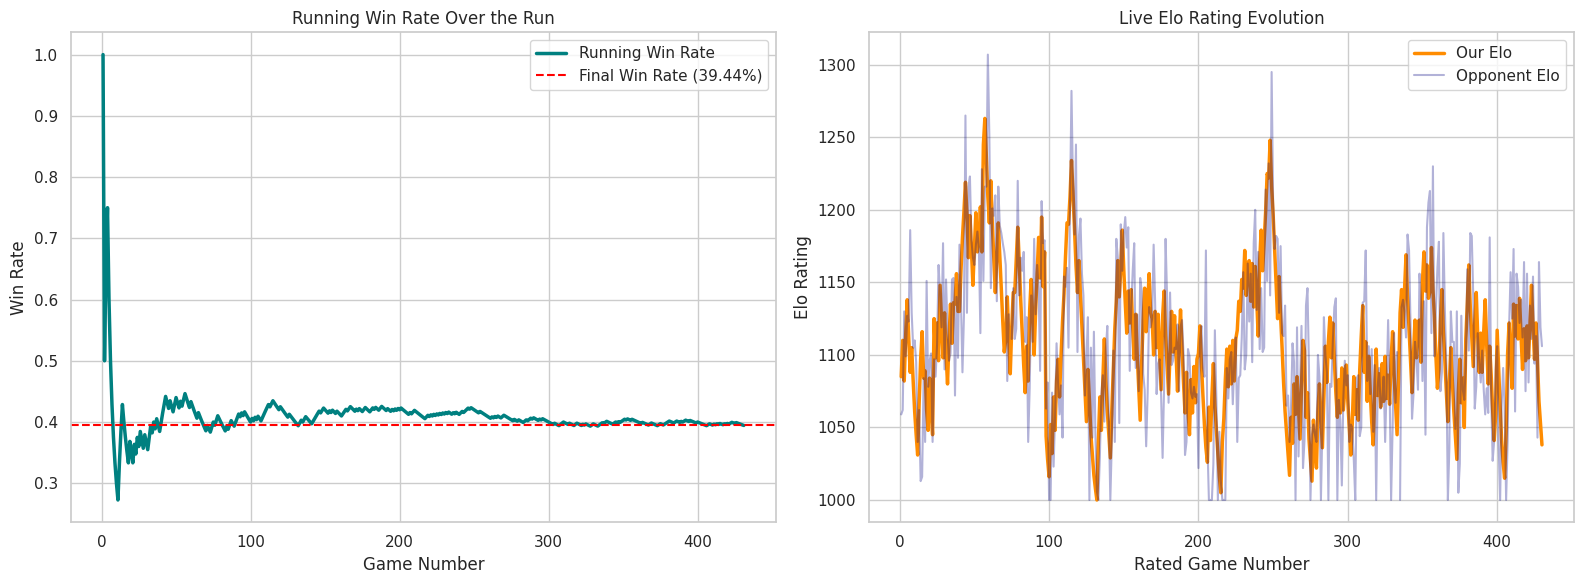

In [3]:
df['cum_wins'] = df['won'].cumsum()
df['cum_games'] = range(1, len(df) + 1)
df['running_win_rate'] = df['cum_wins'] / df['cum_games']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Running Win Rate
axes[0].plot(df['cum_games'], df['running_win_rate'], label='Running Win Rate', color='teal', linewidth=2.5)
axes[0].axhline(df['won'].mean(), color='red', linestyle='--', label=f'Final Win Rate ({df["won"].mean():.2%})')
axes[0].set_title('Running Win Rate Over the Run')
axes[0].set_xlabel('Game Number')
axes[0].set_ylabel('Win Rate')
axes[0].legend()

# Elo Rating Evolution
# Filter to games where ratings were updated (non-empty, non-null values)
rated_df = df[df['rating_us'].notna() & (df['rating_us'] != '') & (df['rating_us'].astype(str) != 'nan')]
if len(rated_df) > 0:
    axes[1].plot(range(1, len(rated_df) + 1), rated_df['rating_us'].astype(float), label='Our Elo', color='darkorange', linewidth=2.5)
    if 'rating_opp' in rated_df.columns:
        axes[1].plot(range(1, len(rated_df) + 1), rated_df['rating_opp'].astype(float), label='Opponent Elo', color='navy', alpha=0.3)
    axes[1].set_title('Live Elo Rating Evolution')
    axes[1].set_xlabel('Rated Game Number')
    axes[1].set_ylabel('Elo Rating')
    axes[1].legend()
else:
    axes[1].text(0.5, 0.5, 'No Elo changes recorded in this run', ha='center', va='center')
    axes[1].set_title('Live Elo Rating Evolution')

plt.tight_layout()
plt.savefig('live_ladder_evolution.png')
plt.show()

## 4. Decisions, Fallbacks, and Error Analysis

We audit the decision logs to see if there were any code exceptions resulting in fallback or error moves.

In [4]:
df_filtered['decisions_per_turn'] = df_filtered['decisions_us'] / df_filtered['turns']
print(f"Avg decisions per turn: {df_filtered['decisions_per_turn'].mean():.2f}")
print(f"Total fallback moves logged (Us): {df['fallback_moves_us'].sum()}")
print(f"Total fallback moves logged (Opponent): {df['fallback_moves_opp'].sum()}")
print(f"Total error moves logged (Us): {df['error_moves_us'].sum()} (Should ideally be 0)")
print(f"Total error moves logged (Opponent): {df['error_moves_opp'].sum()}")

Avg decisions per turn: 1.24
Total fallback moves logged (Us): 13
Total fallback moves logged (Opponent): 0
Total error moves logged (Us): 0 (Should ideally be 0)
Total error moves logged (Opponent): 0


## 5. Team Health and Fainted Pokémon Metrics

How close were our matches? We analyze the number of fainted Pokémon and the remaining HP ratios.

In [5]:
health_analysis = df_filtered.groupby('won').agg(
    avg_fainted_us=('fainted_us', 'mean'),
    avg_fainted_opp=('fainted_opp', 'mean'),
    avg_hp_perc_us=('hp_perc_us', 'mean'),
    avg_hp_perc_opp=('hp_perc_opp', 'mean'),
    avg_turns=('turns', 'mean')
).reset_index()
print("Health & Fainting Metrics grouped by Match Outcome (0=Loss, 1=Win):")
print(health_analysis.to_string(index=False))

Health & Fainting Metrics grouped by Match Outcome (0=Loss, 1=Win):
 won  avg_fainted_us  avg_fainted_opp  avg_hp_perc_us  avg_hp_perc_opp  avg_turns
   0        6.000000         3.229572        0.000000         0.201518  21.610895
   1        3.397163         4.971631        0.342121         0.067674  19.326241


## 6. Switching and Turn Dynamics

In [6]:
switch_analysis = df_filtered.groupby('won').agg(
    vol_switches_us=('voluntary_switches_us', 'mean'),
    forced_switches_us=('forced_switches_us', 'mean'),
    vol_switches_opp=('voluntary_switches_opp', 'mean'),
    forced_switches_opp=('forced_switches_opp', 'mean')
).reset_index()
print("Switching Behavior grouped by Match Outcome:")
print(switch_analysis.to_string(index=False))

Switching Behavior grouped by Match Outcome:
 won  vol_switches_us  forced_switches_us  vol_switches_opp  forced_switches_opp
   0         2.424125            5.233463          3.357977             3.225681
   1         2.191489            3.531915          3.262411             4.191489


## 7. RNG Factor Analysis (Criticals, Misses, Super-Effectives)

In [7]:
rng_analysis = df_filtered.groupby('won').agg(
    avg_crits_us=('crit_us', 'mean'),
    avg_crits_opp=('crit_opp', 'mean'),
    avg_misses_us=('miss_us', 'mean'),
    avg_misses_opp=('miss_opp', 'mean'),
    avg_supereff_us=('supereffective_us', 'mean'),
    avg_supereff_opp=('supereffective_opp', 'mean')
).reset_index()
print("RNG Metrics grouped by Match Outcome:")
print(rng_analysis.to_string(index=False))

RNG Metrics grouped by Match Outcome:
 won  avg_crits_us  avg_crits_opp  avg_misses_us  avg_misses_opp  avg_supereff_us  avg_supereff_opp
   0      0.653696       0.603113       0.315175        0.361868         3.062257          4.474708
   1      0.680851       0.319149       0.177305        0.446809         4.212766          2.936170


## 8. Strategy Feature Analysis (Hazards, Setup, KO Checks)

We evaluate how much the bot's custom heuristics contributed to wins vs losses.

In [8]:
strategy_analysis = df_filtered.groupby('won').agg(
    avg_hazard_sets_us=('hazard_sets_us', 'mean'),
    avg_hazard_removals_us=('hazard_removals_us', 'mean'),
    avg_setup_uses_us=('setup_uses_us', 'mean'),
    avg_ko_checks_us=('ko_checks_us', 'mean'),
    avg_matchup_switches_us=('matchup_switches_us', 'mean')
).reset_index()
print("Bot Custom Heuristics grouped by Match Outcome:")
print(strategy_analysis.to_string(index=False))

Bot Custom Heuristics grouped by Match Outcome:
 won  avg_hazard_sets_us  avg_hazard_removals_us  avg_setup_uses_us  avg_ko_checks_us  avg_matchup_switches_us
   0            0.050584                0.019455           0.035019         16.027237                 1.291829
   1            0.035461                0.007092           0.014184         16.290780                 1.092199


## 9. Terastallization Impact (Gen 9 Special)

In [9]:
print("Terastallization cross-tabulation (Win Rate per quadrant):")
tera_crosstab = pd.crosstab(
    df_filtered['terastallized_us'],
    df_filtered['terastallized_opp'],
    values=df_filtered['won'],
    aggfunc=['mean', 'count']
)
print(tera_crosstab)

Terastallization cross-tabulation (Win Rate per quadrant):
                       mean           count     
terastallized_opp         0         1     0    1
terastallized_us                                
0                  0.382166  0.367347   157  196
1                  0.120000  0.300000    25   20


## 10. Most Common Pokémon in our Teams

In [10]:
def extract_pokemon_names(team_str):
    if pd.isna(team_str) or not isinstance(team_str, str):
        return []
    # Split by '|' and isolate the name before the parenthesis '(' 
    return [p.split('(')[0].strip() for p in team_str.split('|') if p]

all_our_pokemon = []
for t in df_filtered['team_us']:
    all_our_pokemon.extend(extract_pokemon_names(t))

our_pokemon_series = pd.Series(all_our_pokemon)
print("Top 15 most common Pokémon given to our bot:")
print(our_pokemon_series.value_counts().head(15))

Top 15 most common Pokémon given to our bot:
ironthorns     13
plusle         13
mismagius      13
gogoat         12
dragapult      12
bastiodon      12
tropius        12
espathra       11
snorlax        11
ironboulder    11
ludicolo       11
uxie           11
blastoise      11
spidops        11
swalot         11
Name: count, dtype: int64


## 11. Most Used Moves

In [11]:
def parse_move_counts(move_str):
    if pd.isna(move_str) or not isinstance(move_str, str):
        return {}
    result = {}
    for part in move_str.split('|'):
        if ':' in part:
            move_id, count = part.split(':')
            result[move_id.strip()] = int(count)
    return result

total_moves_dict = {}
for m_str in df_filtered['move_stats_us']:
    m_counts = parse_move_counts(m_str)
    for move, count in m_counts.items():
        total_moves_dict[move] = total_moves_dict.get(move, 0) + count

move_series = pd.Series(total_moves_dict).sort_values(ascending=False)
print("Top 15 most executed moves by our bot:")
print(move_series.head(15))

Top 15 most executed moves by our bot:
earthquake     444
knockoff       291
shadowball     248
closecombat    239
thunderbolt    220
moonblast      181
bravebird      155
icebeam        124
psyshock       116
drainpunch      93
outrage         91
bodyslam        91
ironhead        90
dracometeor     90
psychic         89
dtype: int64
